In [ ]:
from google.colab import files

uploaded = files.upload()

Saving smart_ecommerce_customer_support_dataset.csv to smart_ecommerce_customer_support_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("smart_ecommerce_customer_support_dataset.csv")

df.head()

,Ticket_ID,Customer_Query,Category,Department,Priority,Sentiment,Confidence_Score,Escalation_Count,Previous_Transfers,Resolution_Time_Hours,Misrouted
0,1001,My order is delayed,Delivery Issue,Delivery Team,Low,Positive,0.60,0,2,55,Yes
1,1002,Where is my order? and product size is incorrect,Order Status,Order Support,Medium,Negative,0.87,3,0,58,Yes
2,1003,Payment failed,Payment Issue,Payment Team,Low,Negative,0.67,1,1,14,Yes
3,1004,Delivery date changed and damaged product,Delivery Issue,Delivery Team,Low,Positive,0.75,0,1,11,Yes
4,1005,Card payment error,Payment Issue,Payment Team,High,Negative,0.86,0,2,30,Yes


In [ ]:

import os

print(os.listdir())

['.config', 'smart_ecommerce_customer_support_dataset.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("smart_ecommerce_customer_support_dataset.csv")

df.head()

,Ticket_ID,Customer_Query,Category,Department,Priority,Sentiment,Confidence_Score,Escalation_Count,Previous_Transfers,Resolution_Time_Hours,Misrouted
0,1001,My order is delayed,Delivery Issue,Delivery Team,Low,Positive,0.60,0,2,55,Yes
1,1002,Where is my order? and product size is incorrect,Order Status,Order Support,Medium,Negative,0.87,3,0,58,Yes
2,1003,Payment failed,Payment Issue,Payment Team,Low,Negative,0.67,1,1,14,Yes
3,1004,Delivery date changed and damaged product,Delivery Issue,Delivery Team,Low,Positive,0.75,0,1,11,Yes
4,1005,Card payment error,Payment Issue,Payment Team,High,Negative,0.86,0,2,30,Yes


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              10000 non-null  int64  
 1   Customer_Query         10000 non-null  object 
 2   Category               10000 non-null  object 
 3   Department             10000 non-null  object 
 4   Priority               10000 non-null  object 
 5   Sentiment              10000 non-null  object 
 6   Confidence_Score       10000 non-null  float64
 7   Escalation_Count       10000 non-null  int64  
 8   Previous_Transfers     10000 non-null  int64  
 9   Resolution_Time_Hours  10000 non-null  int64  
 10  Misrouted              10000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 859.5+ KB


In [ ]:
df.isnull().sum()

,0
Ticket_ID,0
Customer_Query,0
Category,0
Department,0
Priority,0
Sentiment,0
Confidence_Score,0
Escalation_Count,0
Previous_Transfers,0
Resolution_Time_Hours,0


In [ ]:
df["Category"].value_counts()

,count
Category,
Technical Support,1291
Delivery Issue,1282
Payment Issue,1254
Order Status,1246
Refund Request,1237
Return/Replacement,1235
Product Complaint,1232
Account/Login Issue,1223


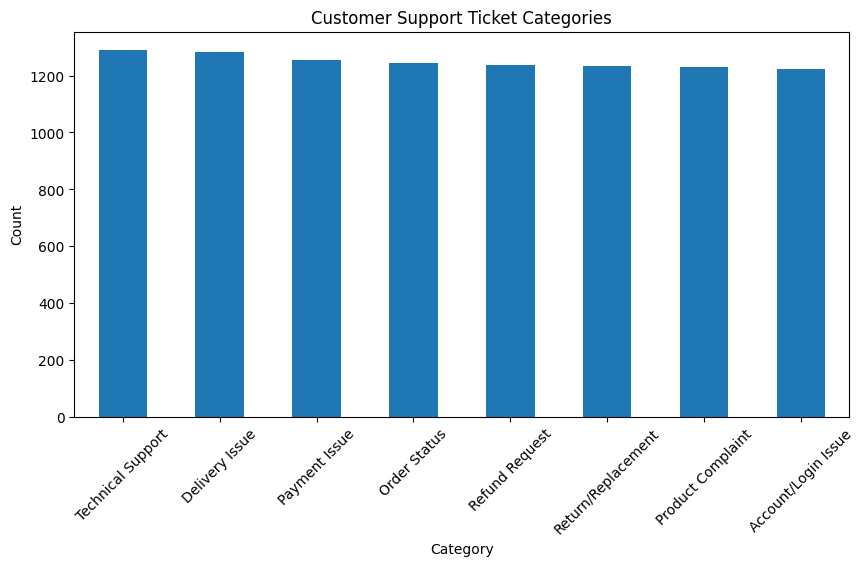

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df["Category"].value_counts().plot(kind="bar")
plt.title("Customer Support Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [ ]:
df["Clean_Query"] = df["Customer_Query"].apply(clean_text)

df[["Customer_Query", "Clean_Query"]].head()

,Customer_Query,Clean_Query
0,My order is delayed,order delayed
1,Where is my order? and product size is incorrect,order product size incorrect
2,Payment failed,payment failed
3,Delivery date changed and damaged product,delivery date changed damaged product
4,Card payment error,card payment error


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Clean_Query"])

y = df["Category"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.887


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

Account/Login Issue       0.89      0.91      0.90       245
     Delivery Issue       0.90      0.87      0.89       256
       Order Status       0.91      0.88      0.89       249
      Payment Issue       0.90      0.87      0.88       251
  Product Complaint       0.90      0.87      0.88       247
     Refund Request       0.87      0.93      0.90       247
 Return/Replacement       0.88      0.86      0.87       247
  Technical Support       0.86      0.91      0.89       258

           accuracy                           0.89      2000
          macro avg       0.89      0.89      0.89      2000
       weighted avg       0.89      0.89      0.89      2000



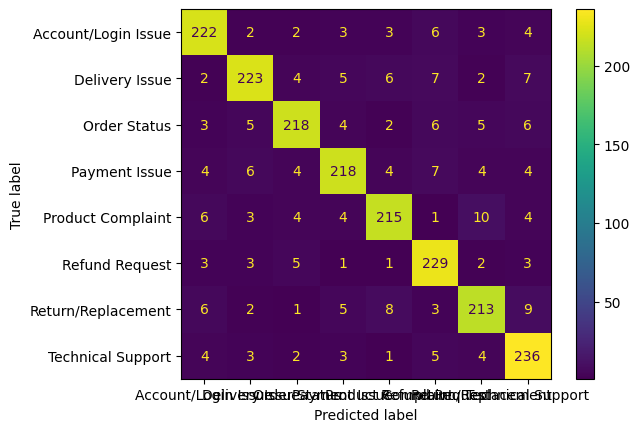

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
X = df[[
    "Priority",
    "Sentiment",
    "Confidence_Score",
    "Escalation_Count",
    "Previous_Transfers",
    "Resolution_Time_Hours"
]]

y = df["Misrouted"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_priority = LabelEncoder()
le_sentiment = LabelEncoder()
le_target = LabelEncoder()

X["Priority"] = le_priority.fit_transform(X["Priority"])
X["Sentiment"] = le_sentiment.fit_transform(X["Sentiment"])

y = le_target.fit_transform(y)

/tmp/ipykernel_1182/3056834229.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Priority"] = le_priority.fit_transform(X["Priority"])
/tmp/ipykernel_1182/3056834229.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Sentiment"] = le_sentiment.fit_transform(X["Sentiment"])


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

risk_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = risk_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       250
           1       1.00      1.00      1.00      1750

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



                 Feature  Importance
4     Previous_Transfers    0.424835
3       Escalation_Count    0.333221
2       Confidence_Score    0.225753
5  Resolution_Time_Hours    0.011930
0               Priority    0.002179
1              Sentiment    0.002083


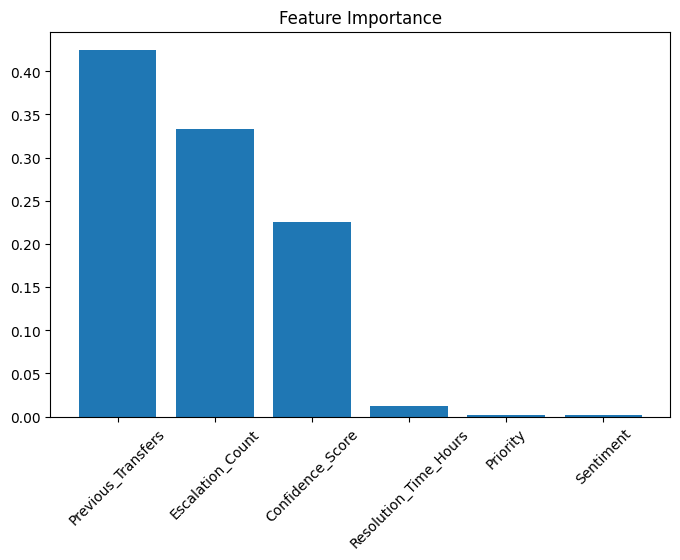

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": risk_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving smart_ecommerce_customer_support_dataset.csv to smart_ecommerce_customer_support_dataset.csv


DATASET SHAPE
(10000, 11)

FIRST 5 RECORDS
   Ticket_ID                                    Customer_Query  \
0       1001                               My order is delayed   
1       1002  Where is my order? and product size is incorrect   
2       1003                                    Payment failed   
3       1004         Delivery date changed and damaged product   
4       1005                                Card payment error   

         Category     Department Priority Sentiment  Confidence_Score  \
0  Delivery Issue  Delivery Team      Low  Positive              0.60   
1    Order Status  Order Support   Medium  Negative              0.87   
2   Payment Issue   Payment Team      Low  Negative              0.67   
3  Delivery Issue  Delivery Team      Low  Positive              0.75   
4   Payment Issue   Payment Team     High  Negative              0.86   

   Escalation_Count  Previous_Transfers  Resolution_Time_Hours Misrouted  
0                 0                   2       

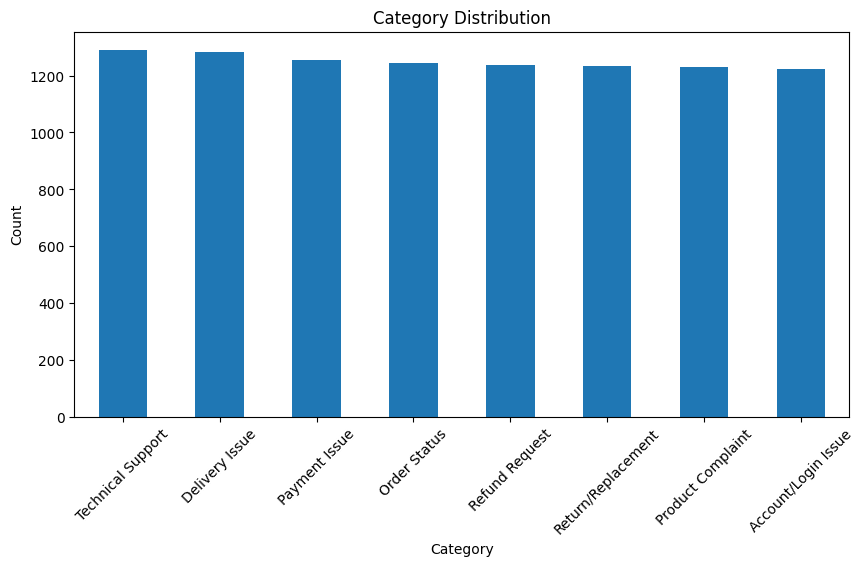

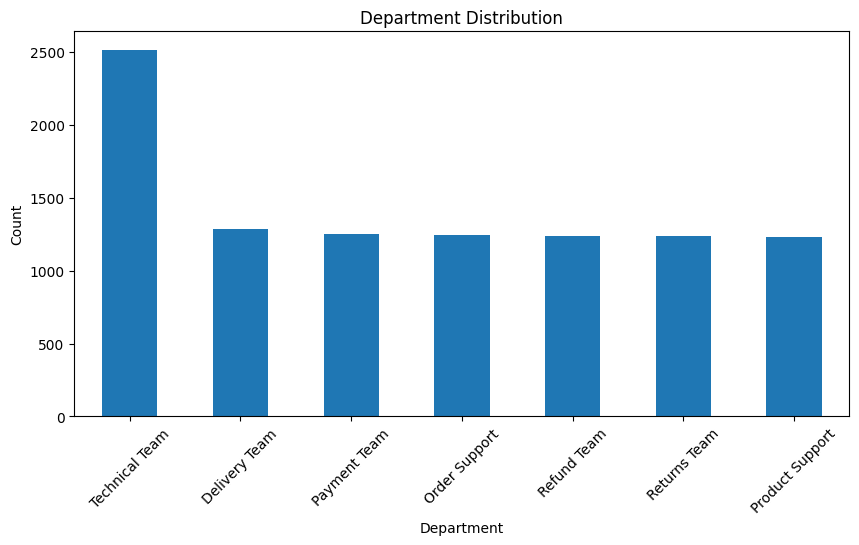

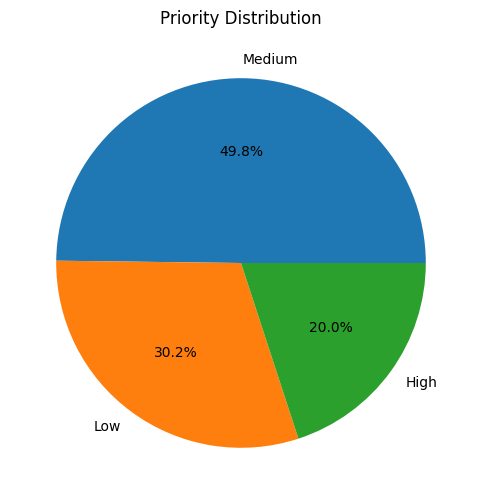

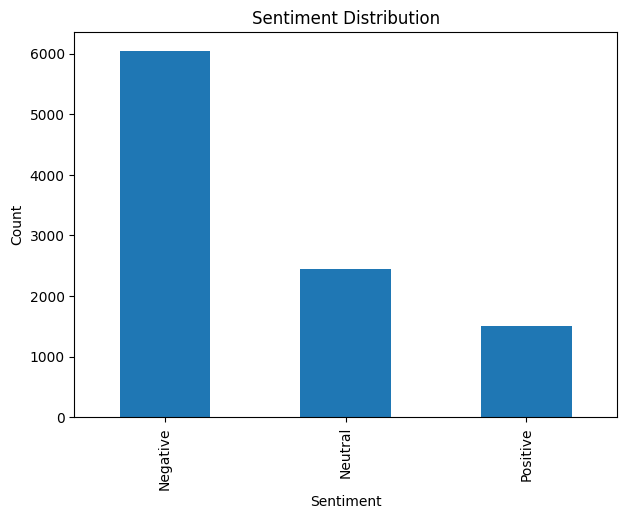

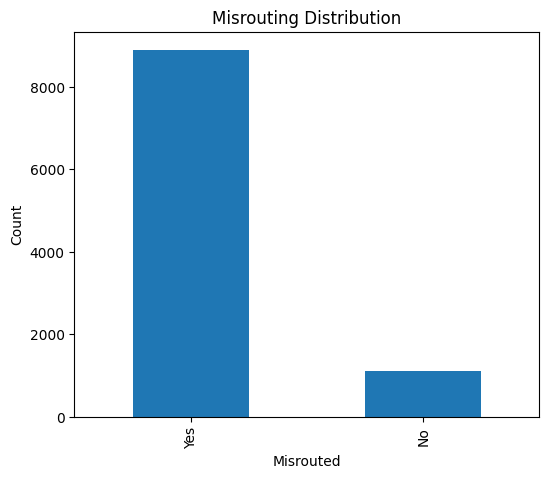

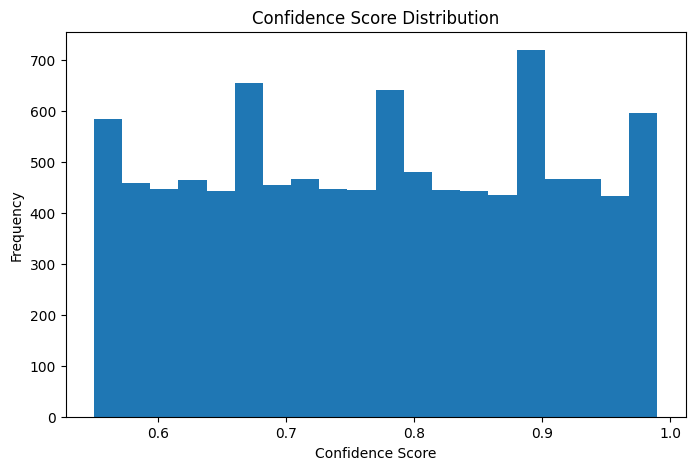

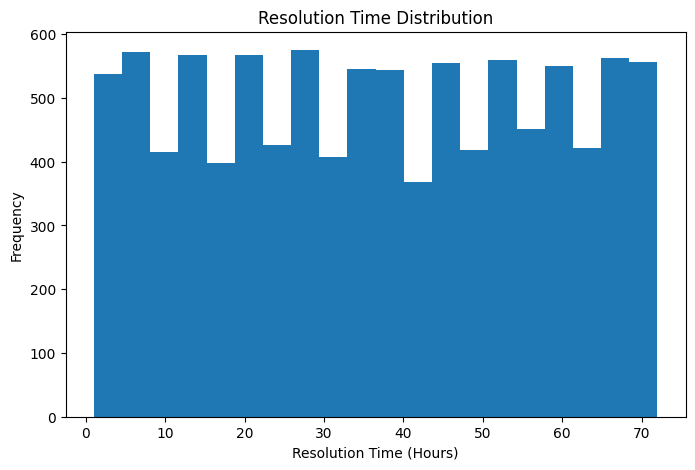


EDA COMPLETED SUCCESSFULLY!


In [ ]:
# ================================
# Exploratory Data Analysis (EDA)
# ================================

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("smart_ecommerce_customer_support_dataset.csv")

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("FIRST 5 RECORDS")
print("="*60)
print(df.head())

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns)

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("DUPLICATE RECORDS")
print("="*60)
print(df.duplicated().sum())

# -------------------------------
# Category Distribution
# -------------------------------
plt.figure(figsize=(10,5))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# Department Distribution
# -------------------------------
plt.figure(figsize=(10,5))
df["Department"].value_counts().plot(kind="bar")
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# Priority Distribution
# -------------------------------
plt.figure(figsize=(6,6))
df["Priority"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Priority Distribution")
plt.ylabel("")
plt.show()

# -------------------------------
# Sentiment Distribution
# -------------------------------
plt.figure(figsize=(7,5))
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# -------------------------------
# Misrouting Distribution
# -------------------------------
plt.figure(figsize=(6,5))
df["Misrouted"].value_counts().plot(kind="bar")
plt.title("Misrouting Distribution")
plt.xlabel("Misrouted")
plt.ylabel("Count")
plt.show()

# -------------------------------
# Confidence Score Distribution
# -------------------------------
plt.figure(figsize=(8,5))
plt.hist(df["Confidence_Score"], bins=20)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# Resolution Time Distribution
# -------------------------------
plt.figure(figsize=(8,5))
plt.hist(df["Resolution_Time_Hours"], bins=20)
plt.title("Resolution Time Distribution")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Frequency")
plt.show()

print("\nEDA COMPLETED SUCCESSFULLY!")

In [ ]:
# Save the current dataframe
df.to_csv("ecommerce_customer_support_dataset_after_eda.csv", index=False)

In [ ]:
from google.colab import files

files.download("ecommerce_customer_support_dataset_after_eda.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# feature_extractor.py
"""
Member 1 Module: Text Preprocessing + TF-IDF Feature Extraction
Converts raw customer complaint text into numeric feature vectors.
"""

import re
import pickle
import logging
from sklearn.feature_extraction.text import TfidfVectorizer

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class TextPreprocessor:
    """Cleans and normalizes raw customer text before vectorization."""

    def __init__(self):
        # Basic stopwords list (can be extended with nltk.corpus.stopwords)
        self.stopwords = {
            "a", "an", "the", "is", "are", "was", "were", "i", "my", "me",
            "and", "to", "of", "in", "on", "for", "it", "this", "that"
        }

    def clean(self, text: str) -> str:
        """
        Lowercases, removes punctuation/numbers, strips stopwords.

        Args:
            text: raw customer complaint string

        Returns:
            cleaned string ready for vectorization
        """
        if not isinstance(text, str):
            raise ValueError("Input text must be a string")

        text = text.lower()
        text = re.sub(r"[^a-z\s]", " ", text)          # remove punctuation/numbers
        text = re.sub(r"\s+", " ", text).strip()        # collapse whitespace

        tokens = [w for w in text.split() if w not in self.stopwords]
        return " ".join(tokens)


class TFIDFFeatureExtractor:
    """Wraps sklearn's TfidfVectorizer with fit/transform/save/load."""

    def __init__(self, max_features: int = 3000):
        self.vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))
        self.preprocessor = TextPreprocessor()
        self.is_fitted = False

    def fit_transform(self, texts: list[str]):
        """Fit vectorizer on training corpus and return TF-IDF matrix."""
        cleaned = [self.preprocessor.clean(t) for t in texts]
        matrix = self.vectorizer.fit_transform(cleaned)
        self.is_fitted = True
        logger.info(f"TF-IDF fitted. Vocabulary size: {len(self.vectorizer.vocabulary_)}")
        return matrix

    def transform(self, texts: list[str]):
        """Transform new/unseen text using the already-fitted vectorizer."""
        if not self.is_fitted:
            raise RuntimeError("Vectorizer not fitted yet. Call fit_transform first.")
        cleaned = [self.preprocessor.clean(t) for t in texts]
        return self.vectorizer.transform(cleaned)

    def save(self, path: str = "tfidf_vectorizer.pkl"):
        with open(path, "wb") as f:
            pickle.dump(self.vectorizer, f)
        logger.info(f"Vectorizer saved to {path}")

    def load(self, path: str = "tfidf_vectorizer.pkl"):
        with open(path, "rb") as f:
            self.vectorizer = pickle.load(f)
        self.is_fitted = True
        logger.info(f"Vectorizer loaded from {path}")


if __name__ == "__main__":
    sample_texts = [
        "My payment was deducted but order not delivered",
        "I want a refund for my damaged product",
        "The app keeps crashing when I login",
        "My order delivery is delayed",
    ]
    extractor = TFIDFFeatureExtractor()
    vectors = extractor.fit_transform(sample_texts)
    print("Shape of TF-IDF matrix:", vectors.shape)
    extractor.save()

Shape of TF-IDF matrix: (4, 31)


In [4]:
# ===========================================
# CUSTOMER SUPPORT TICKET CLASSIFICATION
# RANDOM FOREST MODEL
# ===========================================

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

# ===========================================
# Load Dataset
# ===========================================

df = pd.read_csv("ecommerce_customer_support_dataset.csv")

print("Dataset Shape:", df.shape)

print(df.head())

# ===========================================
# Features & Target
# ===========================================

X = df["Customer_Query"]

y = df["Category"]

# ===========================================
# Train Test Split
# ===========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ===========================================
# TF-IDF + Random Forest Pipeline
# ===========================================

model = Pipeline([

    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1,2),
        max_features=5000
    )),

    ("rf", RandomForestClassifier(

        n_estimators=300,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        random_state=42,
        n_jobs=-1

    ))

])

# ===========================================
# Train Model
# ===========================================

model.fit(X_train, y_train)

# ===========================================
# Prediction
# ===========================================

y_pred = model.predict(X_test)

# ===========================================
# Accuracy
# ===========================================

accuracy = accuracy_score(y_test, y_pred)

print("\n====================================")
print("Accuracy :", round(accuracy*100,2),"%")
print("====================================")

# ===========================================
# Classification Report
# ===========================================

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

# ===========================================
# Confusion Matrix
# ===========================================

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ===========================================
# Test with New Query
# ===========================================

sample = [

"Payment deducted but order not confirmed"

]

prediction = model.predict(sample)

print("\nCustomer Query : ",sample[0])

print("Predicted Category :",prediction[0])

FileNotFoundError: [Errno 2] No such file or directory: 'ecommerce_customer_support_dataset.csv'

In [5]:
import os

print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'sample_data']


In [7]:
df = pd.read_csv("ecommerce_customer_support_dataset_after_eda.csv")

In [9]:
import os

print(os.listdir())

['.config', 'ecommerce_customer_support_dataset_after_eda.csv', 'tfidf_vectorizer.pkl', 'sample_data']


In [10]:
df = pd.read_csv("ecommerce_customer_support_dataset_after_eda.csv")

In [13]:
import pandas as pd

# Load Uploaded Dataset
df = pd.read_csv("/content/ecommerce_customer_support_dataset_after_eda.csv")

print(df.head())
print(df.shape)

   Ticket_ID                                    Customer_Query  \
0       1001                               My order is delayed   
1       1002  Where is my order? and product size is incorrect   
2       1003                                    Payment failed   
3       1004         Delivery date changed and damaged product   
4       1005                                Card payment error   

         Category     Department Priority Sentiment  Confidence_Score  \
0  Delivery Issue  Delivery Team      Low  Positive              0.60   
1    Order Status  Order Support   Medium  Negative              0.87   
2   Payment Issue   Payment Team      Low  Negative              0.67   
3  Delivery Issue  Delivery Team      Low  Positive              0.75   
4   Payment Issue   Payment Team     High  Negative              0.86   

   Escalation_Count  Previous_Transfers  Resolution_Time_Hours Misrouted  
0                 0                   2                     55       Yes  
1             

Dataset Loaded Successfully
Dataset Shape: (10000, 11)

Training Random Forest Model...
Training Completed!

Accuracy : 93.1 %

Classification Report

                     precision    recall  f1-score   support

Account/Login Issue       0.92      0.96      0.94       245
     Delivery Issue       0.95      0.92      0.93       256
       Order Status       0.96      0.94      0.95       249
      Payment Issue       0.93      0.92      0.93       251
  Product Complaint       0.93      0.92      0.92       247
     Refund Request       0.91      0.95      0.93       247
 Return/Replacement       0.92      0.90      0.91       247
  Technical Support       0.93      0.95      0.94       258

           accuracy                           0.93      2000
          macro avg       0.93      0.93      0.93      2000
       weighted avg       0.93      0.93      0.93      2000



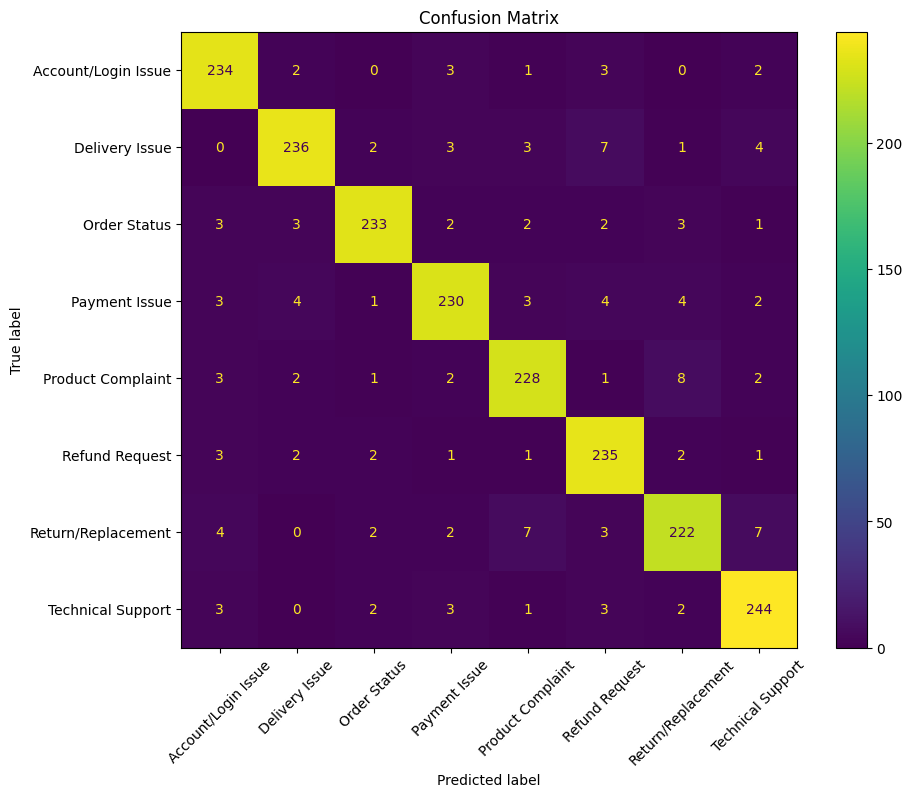


========== SAMPLE PREDICTIONS ==========

Customer Query : Payment deducted but order not confirmed
Predicted Category : Payment Issue
-------------------------------------
Customer Query : Refund not received
Predicted Category : Refund Request
-------------------------------------
Customer Query : My product arrived damaged
Predicted Category : Product Complaint
-------------------------------------
Customer Query : Unable to login to my account
Predicted Category : Account/Login Issue
-------------------------------------
Customer Query : Where is my order?
Predicted Category : Order Status
-------------------------------------
Customer Query : I want to replace the product
Predicted Category : Return/Replacement
-------------------------------------


In [17]:
# ==========================================
# RANDOM FOREST - CUSTOMER SUPPORT MULTICLASS CLASSIFICATION
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# -------------------------
# Load Dataset
# -------------------------
df = pd.read_csv("/content/ecommerce_customer_support_dataset_after_eda.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

# -------------------------
# Features & Target
# -------------------------
X = df["Customer_Query"]
y = df["Category"]

# -------------------------
# Train Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# Create Pipeline
# -------------------------
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        lowercase=True,
        max_features=5000,
        ngram_range=(1,2)
    )),

    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# -------------------------
# Train Model
# -------------------------
print("\nTraining Random Forest Model...")
pipeline.fit(X_train, y_train)
print("Training Completed!")

# -------------------------
# Prediction
# -------------------------
y_pred = pipeline.predict(X_test)

# -------------------------
# Accuracy
# -------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("==============================")

# -------------------------
# Classification Report
# -------------------------
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_
)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# Sample Prediction
# -------------------------
sample_queries = [
    "Payment deducted but order not confirmed",
    "Refund not received",
    "My product arrived damaged",
    "Unable to login to my account",
    "Where is my order?",
    "I want to replace the product"
]

predictions = pipeline.predict(sample_queries)

print("\n========== SAMPLE PREDICTIONS ==========\n")

for query, pred in zip(sample_queries, predictions):
    print("Customer Query :", query)
    print("Predicted Category :", pred)
    print("-------------------------------------")